In [37]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import math

rng = np.random.default_rng(seed=6420)

## Problem 1

In [ ]:
clutch_data = pd.read_csv('clutch.csv')
clutch_data.head()

,Player,Overall_proportion,Clutch_makes,Clutch_attempts
0,Russell Westbrook,0.845,64,75
1,James Harden,0.847,72,95
2,Kawhi Leonard,0.880,55,63
3,LeBron James,0.674,27,39
4,Isaiah Thomas,0.909,75,83


In [39]:
shape = clutch_data.shape
y = clutch_data['Clutch_makes'].values
prop_success = clutch_data['Overall_proportion'].values
num_attempts = clutch_data['Clutch_attempts'].values
player_names = clutch_data['Player'].values

In [40]:
with pm.Model(coords={"player": player_names}) as q1_model:
    n = pm.Data('n', num_attempts)
    q = pm.Data('q', prop_success)
    # Priors
    m = pm.Gamma('m', alpha=0.001, beta=0.001)
    theta = pm.Beta('theta', m*q, m*(1-q), shape=shape[0], dims="player")
    # Likelihood
    y_obs = pm.Binomial('y_obs', n=n, p=theta, observed=y)

    trace = pm.sample(10000, tune=2000, nuts_sampler="nutpie", target_accept=0.95)

d:\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,12000,0,0.35,15
,12000,0,0.29,15
,12000,0,0.33,15
,12000,0,0.30,15


In [41]:
print(az.summary(trace, var_names=['theta', 'm'], hdi_prob=0.95).to_markdown())

|                              |    mean |      sd |   hdi_2.5% |   hdi_97.5% |   mcse_mean |   mcse_sd |   ess_bulk |   ess_tail |   r_hat |
|:-----------------------------|--------:|--------:|-----------:|------------:|------------:|----------:|-----------:|-----------:|--------:|
| theta[Russell Westbrook]     |   0.847 |   0.021 |      0.801 |       0.889 |       0     |     0     |      46473 |      20943 |       1 |
| theta[James Harden]          |   0.82  |   0.027 |      0.761 |       0.863 |       0     |     0     |      11308 |      22217 |       1 |
| theta[Kawhi Leonard]         |   0.878 |   0.02  |      0.837 |       0.918 |       0     |     0     |      47366 |      22717 |       1 |
| theta[LeBron James]          |   0.677 |   0.031 |      0.615 |       0.743 |       0     |     0     |      40139 |      18914 |       1 |
| theta[Isaiah Thomas]         |   0.907 |   0.017 |      0.872 |       0.94  |       0     |     0     |      50775 |      23091 |       1 |
| thet

Text(0.5, 1.0, 'Posterior distribution of clutch shooting percentage')

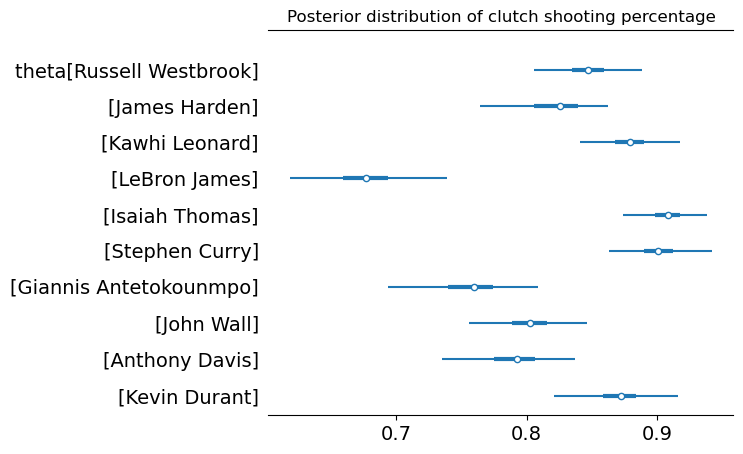

In [42]:
# Forest plot the posterior distribution for each player's clutch shooting percentage
az.plot_forest(trace, var_names=['theta'], combined=True)
plt.title('Posterior distribution of clutch shooting percentage')

In [43]:
with pm.Model(coords={"player": player_names}) as q1_2_model:
    n = pm.Data('n', num_attempts)
    q = pm.Data('q', prop_success)
    # Priors
    beta = pm.Normal('beta', mu=0, sigma=10)
    logit_theta = beta + pm.logit(q)

    # Likelihood
    y_obs = pm.Binomial('y_obs', n=n, p=pm.invlogit(logit_theta), observed=y)

    trace_1_2 = pm.sample(10000, tune=2000, nuts_sampler="nutpie", target_accept=0.95)

d:\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,12000,0,0.94,3
,12000,0,0.80,1
,12000,0,0.84,3
,12000,0,0.85,3


In [44]:
print(az.summary(trace_1_2, var_names=['beta'], hdi_prob=0.95).to_markdown())

|      |   mean |    sd |   hdi_2.5% |   hdi_97.5% |   mcse_mean |   mcse_sd |   ess_bulk |   ess_tail |   r_hat |
|:-----|-------:|------:|-----------:|------------:|------------:|----------:|-----------:|-----------:|--------:|
| beta | -0.179 | 0.108 |     -0.391 |       0.029 |       0.001 |     0.001 |      15527 |      16053 |       1 |


Text(0.5, 1.0, 'Posterior distribution of beta for clutch shooting percentage')

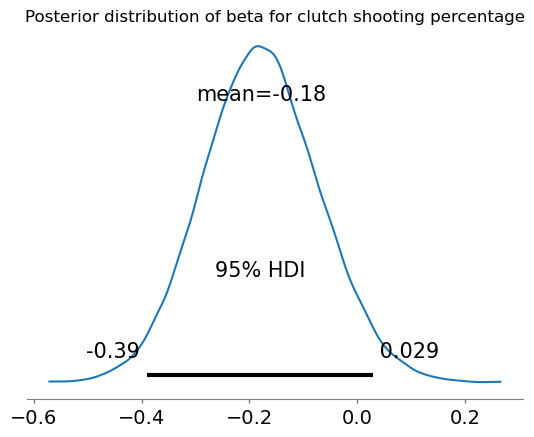

In [45]:
# Plot posterior density of beta
az.plot_posterior(trace_1_2, var_names=['beta'], hdi_prob=0.95)
plt.title('Posterior distribution of beta for clutch shooting percentage')

## Question 2

In [ ]:
sleep_data = pd.read_csv('sleep.csv')
sleep_data.head()

,mammal,body,brain,nondream,dream,sleep,lifespan,gestation,predation,exposure,danger
0,African.elephant,6654.000,5712.0,NaN,NaN,3.3,38.6,645.0,3,5,3
1,African.giant.pouched.rat,1.000,6.6,6.3,2.0,8.3,4.5,42.0,3,1,3
2,Arctic.Fox,3.385,44.5,NaN,NaN,12.5,14.0,60.0,1,1,1
3,Arctic.ground.squirrel,0.920,5.7,NaN,NaN,16.5,NaN,25.0,5,2,3
4,Asian.elephant,2547.000,4603.0,2.1,1.8,3.9,69.0,624.0,3,5,4


In [47]:
y_sleep = (sleep_data['dream']/sleep_data['sleep']).values
animal_names = sleep_data['mammal'].values
X_sleep = sleep_data.drop(columns=['dream', 'nondream', 'sleep', 'mammal'])
predictor_names = X_sleep.columns.tolist()
# x1, x2, x3, x4 are log-transformed
x1_4 = np.log(X_sleep.values[:, :4])
print("Performing log transformation on columns:", X_sleep.columns[:4].tolist())
X_sleep = np.hstack((x1_4, X_sleep.values[:, 4:]))
# Get number of missing in each column
num_missing = np.sum(np.isnan(X_sleep), axis=0)
print("Number of missing values in each column:", num_missing)

Performing log transformation on columns: ['body', 'brain', 'lifespan', 'gestation']
Number of missing values in each column: [0 0 4 4 0 0 0]


In [48]:
# Get mean and variance of x3 and x4 for imputation
x3_mean = np.nanmean(X_sleep[:, 2])
x3_var = np.nanvar(X_sleep[:, 2])
print(f"Mean of x3: {x3_mean}, Variance of x3: {x3_var}")
x4_mean = np.nanmean(X_sleep[:, 3])
x4_var = np.nanvar(X_sleep[:, 3])   
print(f"Mean of x4: {np.nanmean(X_sleep[:, 3])}, Variance of x4: {np.nanvar(X_sleep[:, 3])}")

Mean of x3: 2.59305860512712, Variance of x3: 0.8748710738850211
Mean of x4: 4.4441909549617415, Variance of x4: 1.1047520348993343


In [49]:
# Create mask for missing values
x3_masked = np.ma.masked_invalid(X_sleep[:, 2])
x4_masked = np.ma.masked_invalid(X_sleep[:, 3])
y_masked = np.ma.masked_invalid(y_sleep)
y_masked = np.ma.masked_values(y_masked, value=-1)

In [50]:
# Assuming MCAR and x3, x4 missing values are imputed with mean of Normal distribution
with pm.Model(coords={"animal": animal_names, "predictors": ["intercept"] + predictor_names}) as q2_model:
    # Priors
    m = pm.Gamma('m', alpha=0.001, beta=0.001)
    beta = pm.Normal('beta', mu=0, sigma=10, shape=X_sleep.shape[1]+1, dims="predictors")

    # Impute missing values for x3 and x4
    x3 = pm.Normal('x3', mu=x3_mean, sigma=np.sqrt(x3_var), shape=X_sleep.shape[0], observed=x3_masked)
    x4 = pm.Normal('x4', mu=x4_mean, sigma=np.sqrt(x4_var), shape=X_sleep.shape[0], observed=x4_masked)
    
    logit_mu = (beta[0] + beta[1]*X_sleep[:, 0] + 
                beta[2]*X_sleep[:, 1] + beta[3]*x3 + 
                beta[4]*x4 + beta[5]*X_sleep[:, 4] + 
                beta[6]*X_sleep[:, 5] + beta[7]*X_sleep[:, 6]
    )
    mu = pm.math.invlogit(logit_mu)
    # Likelihood
    y = pm.Beta('y', alpha=m*mu, beta=m*(1-mu), observed=y_masked, dims="animal")

    trace_q2 = pm.sample(10000, tune=2000, nuts_sampler="nutpie", target_accept=0.95)
    pm.compute_log_likelihood(trace_q2)

d:\anaconda3\envs\pymc_env\Lib\site-packages\pymc\model\core.py:1316: ImputationWarning: Data in x3 contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
d:\anaconda3\envs\pymc_env\Lib\site-packages\pymc\model\core.py:1316: ImputationWarning: Data in x4 contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
d:\anaconda3\envs\pymc_env\Lib\site-packages\pymc\model\core.py:1316: ImputationWarning: Data in y contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
d:\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loade

Progress,Draws,Divergences,Step Size,Gradients/Draw
,12000,0,0.12,31
,12000,0,0.13,63
,12000,0,0.12,31
,12000,0,0.12,31


Output()

In [51]:
missing_animal_vals = animal_names[y_masked.mask]
print(az.summary(trace_q2, var_names=["y"], hdi_prob=0.95, coords={"animal": missing_animal_vals}, round_to=3).to_markdown())

|                           |   mean |    sd |   hdi_2.5% |   hdi_97.5% |   mcse_mean |   mcse_sd |   ess_bulk |   ess_tail |   r_hat |
|:--------------------------|-------:|------:|-----------:|------------:|------------:|----------:|-----------:|-----------:|--------:|
| y[African.elephant]       |  0.307 | 0.115 |      0.088 |       0.527 |       0.001 |     0.001 |    28897.7 |    24864.4 |       1 |
| y[Arctic.Fox]             |  0.208 | 0.09  |      0.046 |       0.385 |       0     |     0     |    37344.9 |    24726.3 |       1 |
| y[Arctic.ground.squirrel] |  0.158 | 0.099 |      0     |       0.345 |       0.001 |     0.001 |    12211.7 |    15503.8 |       1 |
| y[Donkey]                 |  0.158 | 0.082 |      0.019 |       0.317 |       0     |     0     |    41640.9 |    23291.9 |       1 |
| y[Giraffe]                |  0.195 | 0.09  |      0.033 |       0.369 |       0     |     0     |    43737.1 |    23943.1 |       1 |
| y[Gorilla]                |  0.308 | 0.116 |  

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

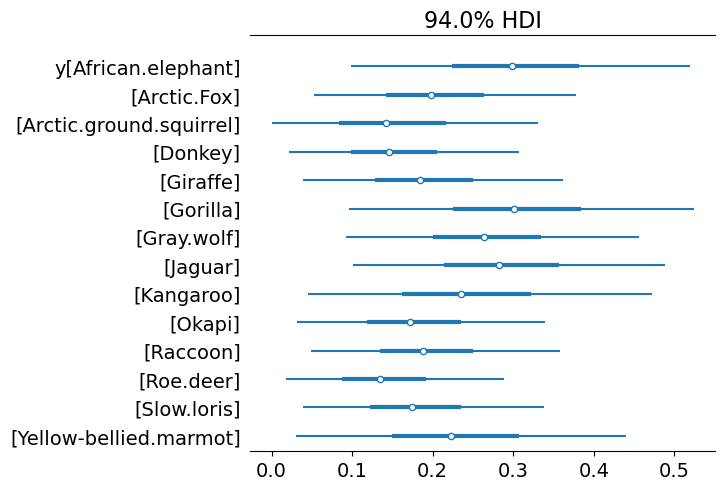

In [52]:
az.plot_forest(trace_q2, var_names=["y"], combined=True, coords={"animal": missing_animal_vals})

In [53]:
with q2_model:
    ppc = pm.sample_posterior_predictive(trace_q2, random_seed=6420, extend_inferencedata=True)
    

Sampling: [x3_observed, x4_observed, y_observed, y_unobserved]


Output()

<Axes: xlabel='y_observed'>

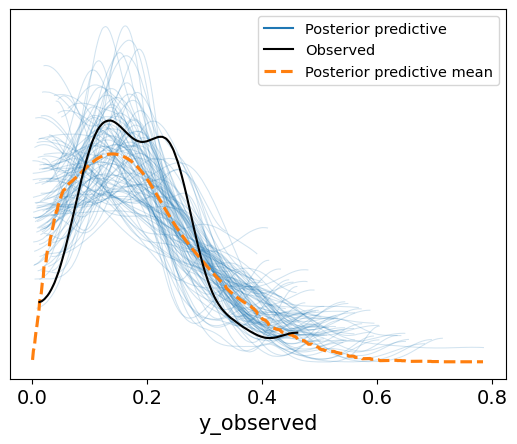

In [54]:
az.plot_ppc(trace_q2, var_names=["y_observed"], num_pp_samples=100)

In [55]:
print(az.summary(trace_q2, var_names=["beta"], hdi_prob=0.95).to_markdown())

|                 |   mean |    sd |   hdi_2.5% |   hdi_97.5% |   mcse_mean |   mcse_sd |   ess_bulk |   ess_tail |   r_hat |
|:----------------|-------:|------:|-----------:|------------:|------------:|----------:|-----------:|-----------:|--------:|
| beta[intercept] | -0.031 | 0.565 |     -1.166 |       1.065 |       0.008 |     0.005 |       5135 |       9175 |       1 |
| beta[body]      |  0.229 | 0.093 |      0.047 |       0.413 |       0.001 |     0.001 |       6404 |      11334 |       1 |
| beta[brain]     | -0.149 | 0.146 |     -0.44  |       0.131 |       0.002 |     0.001 |       5560 |       9094 |       1 |
| beta[lifespan]  | -0.265 | 0.157 |     -0.581 |       0.034 |       0.002 |     0.001 |       6196 |      11660 |       1 |
| beta[gestation] | -0.045 | 0.116 |     -0.276 |       0.178 |       0.001 |     0.001 |       6116 |      10832 |       1 |
| beta[predation] | -0.054 | 0.229 |     -0.518 |       0.385 |       0.003 |     0.002 |       4403 |       7274 |   

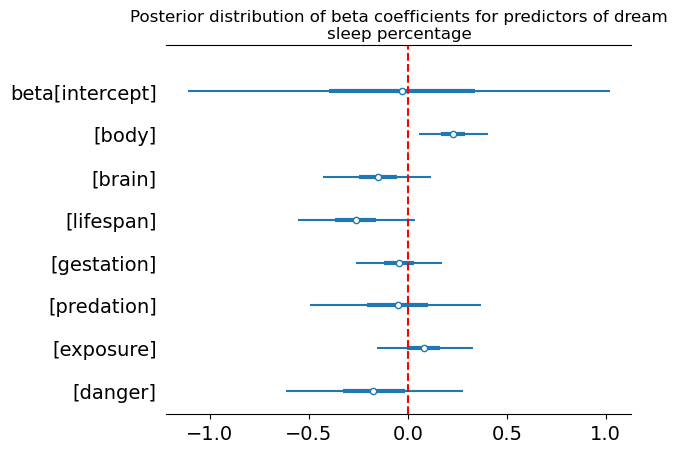

In [56]:
# Plot beta coefficients to asses predictors contribution to dream sleep percentage
az.plot_forest(trace_q2, var_names=["beta"], combined=True)
plt.title('Posterior distribution of beta coefficients for predictors of dream sleep percentage')
plt.axvline(x=0, color='red', linestyle='--')

In [57]:
# Keep only first 4 predictors (log term)
x1 = np.log(sleep_data['body'].values)
x2 = sleep_data['danger'].values
x3 = np.log(sleep_data['lifespan'].values)
x4 = np.log(sleep_data['gestation'].values)

# Mask missing values for x3 and x4
x3_masked = np.ma.masked_invalid(x3)
x4_masked = np.ma.masked_invalid(x4)

# Ensure model is centred around zero for standardized predictors
x_centred_list = []
for i in [x1, x2, x3_masked, x4_masked]:
    mean = np.nanmean(i)
    std = np.nanstd(i)
    x_scaled = (i - mean) / std
    x_centred_list.append(x_scaled)

In [58]:
# Use SSVS
with pm.Model(coords={"predictors": ['body', 'danger', 'lifespan', 'gestation']}) as q2_ssvs_model:
    # Priors
    delta = pm.Bernoulli("delta", p=0.5, shape=len(x_centred_list), dims="predictors")
    m = pm.Gamma('m', alpha=0.001, beta=0.001)

    # Intercept
    alpha_0 = pm.Normal('alpha_0', mu=0, sigma=10)
    # Coefficients with SSVS
    alpha = pm.Normal('alpha', mu=0, sigma=1, shape=len(x_centred_list))
    beta = pm.Deterministic('beta', delta * alpha, dims="predictors")

    # Impute missing values for x3 and x4. Values are now standardized, so mean is 0 and variance is 1
    x3_imputed = pm.Normal('x3_imputed', mu=0, sigma=1, observed=x_centred_list[2])
    x4_imputed = pm.Normal('x4_imputed', mu=0, sigma=1, observed=x_centred_list[3])
    
    logit_mu = (alpha_0 + 
                beta[0]*x_centred_list[0] + 
                beta[1]*x_centred_list[1] + 
                beta[2]*x3_imputed + 
                beta[3]*x4_imputed
    )
    mu = pm.math.invlogit(logit_mu)
    # Likelihood
    y = pm.Beta('y', alpha=m*mu, beta=m*(1-mu), observed=y_masked)

    trace_q2_ssvs = pm.sample(5000, tune=1000, random_seed=6420, target_accept=0.99)
    
print(az.summary(trace_q2_ssvs, var_names=["delta"], hdi_prob=0.95).to_markdown())

d:\anaconda3\envs\pymc_env\Lib\site-packages\pymc\model\core.py:1316: ImputationWarning: Data in x3_imputed contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
d:\anaconda3\envs\pymc_env\Lib\site-packages\pymc\model\core.py:1316: ImputationWarning: Data in x4_imputed contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
d:\anaconda3\envs\pymc_env\Lib\site-packages\pymc\model\core.py:1316: ImputationWarning: Data in y contains missing values and will be automatically imputed from the sampling distribution.
  warnings.warn(impute_message, ImputationWarning)
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>BinaryGibbsMetropolis: [delta]
>NUTS: [m, alpha_0, alpha, x3_imputed_unobserved, x4_imputed_unobserved, y_unobserved]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 217 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


|                  |   mean |    sd |   hdi_2.5% |   hdi_97.5% |   mcse_mean |   mcse_sd |   ess_bulk |   ess_tail |   r_hat |
|:-----------------|-------:|------:|-----------:|------------:|------------:|----------:|-----------:|-----------:|--------:|
| delta[body]      |  0.638 | 0.481 |          0 |           1 |       0.022 |     0.006 |        456 |        456 |    1.01 |
| delta[danger]    |  0.571 | 0.495 |          0 |           1 |       0.019 |     0.003 |        697 |        697 |    1.01 |
| delta[lifespan]  |  0.583 | 0.493 |          0 |           1 |       0.023 |     0.004 |        463 |        463 |    1.01 |
| delta[gestation] |  0.13  | 0.337 |          0 |           1 |       0.005 |     0.005 |       5255 |       5255 |    1    |


In [66]:
chains = 4
draws = 5000
rows = chains * draws

deltas = trace_q2_ssvs.posterior.delta.to_numpy()
models, counts = np.unique(
    deltas.reshape((rows, 4)), axis=0, return_counts=True
)

results = zip(models, counts)
result_list = []
for model, count in sorted(results, key=lambda x: x[1], reverse=True):
    result_list.append((model, count/rows))

df_result = pd.DataFrame(result_list, columns=["Model", "Probability"])
df_result.head()

,Model,Probability
0,"[1, 1, 1, 0]",0.36815
1,"[0, 0, 0, 0]",0.20725
2,"[1, 0, 1, 0]",0.09685
3,"[0, 1, 0, 0]",0.08240
4,"[1, 1, 1, 1]",0.05160


## Question 3

In [67]:
nano_data = pd.read_csv("data/nanowire-2.csv")
nano_data

,x,y
0,0.0,123
1,0.0,123
2,2.5,46
3,2.5,48
4,5.0,8
5,5.0,11
6,7.5,8
7,7.5,7
8,10.0,7
9,10.0,2


In [68]:
# Account for the runs where x that are the same value are considered as belonging to the same run
nano_data['run'] = (nano_data['x'] != nano_data['x'].shift()).cumsum()
nano_data


,x,y,run
0,0.0,123,1
1,0.0,123,1
2,2.5,46,2
3,2.5,48,2
4,5.0,8,3
5,5.0,11,3
6,7.5,8,4
7,7.5,7,4
8,10.0,7,5
9,10.0,2,5


In [ ]:
# Density of wires follows Poission distribution
with pm.Model(coords={"thetas_1_3_4": ["theta1", "theta3", "theta4"], "run": nano_data["run"].unique()}) as wire_model:
    x_data = pm.Data("x", nano_data["x"].to_numpy())
    y_data = pm.Data("y", nano_data["y"].to_numpy())
    run_data = pm.Data("run", nano_data["run"].to_numpy()-1) # -1 so that run indices start from 0
    # Priors
    alpha = pm.Normal("alpha", mu=0, sigma=0.1, shape=len(nano_data["run"].unique()) + 1) # Added +1 for new run with x=2.0
    # define thetas
    theta_2 = pm.Uniform("theta_2", lower=0, upper=1)
    log_thetas_1_3_4 = pm.Normal("log_thetas_1_3_4", mu=0, sigma=math.sqrt(10), shape=3, dims="thetas_1_3_4")
    theta_1 = pm.Deterministic("theta_1", pm.math.exp(log_thetas_1_3_4[0]))
    theta_3 = pm.Deterministic("theta_3", pm.math.exp(log_thetas_1_3_4[1]))
    theta_4 = pm.Deterministic("theta_4", pm.math.exp(log_thetas_1_3_4[2]))
    
    std_normal = pm.Normal.dist(mu=0, sigma=1)
    Psi = pm.invprobit(-x_data/theta_4)
    mu = (
        theta_1*pm.math.exp(-theta_2*x_data**2) + 
        theta_3*(1-pm.math.exp(-theta_2*x_data**2))*Psi
    ) * pm.math.exp(alpha[run_data])

    # Likelihood
    y_obs = pm.Poisson("y_obs", mu=mu, observed=nano_data["y"].to_numpy(), shape=nano_data.shape[0])
    trace_wire = pm.sample(10000, tune=2000, nuts_sampler="nutpie", target_accept=0.95, random_seed=rng)

    new_obs = np.array([2.0])
    pm.set_data({"x": new_obs, "run": np.array([8]), "y": np.array([0])})
    pred_wire = pm.sample_posterior_predictive(
        trace_wire, predictions=True, random_seed=rng
    )

d:\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,12000,0,0.34,15
,12000,0,0.34,31
,12000,0,0.34,15
,12000,0,0.35,15


Sampling: [y_obs]


Output()

In [73]:
print(az.summary(trace_wire, var_names=["theta_1", "theta_2", "theta_3", "theta_4", "alpha"], hdi_prob=0.95).to_markdown())

|          |    mean |     sd |   hdi_2.5% |   hdi_97.5% |   mcse_mean |   mcse_sd |   ess_bulk |   ess_tail |   r_hat |
|:---------|--------:|-------:|-----------:|------------:|------------:|----------:|-----------:|-----------:|--------:|
| theta_1  | 123.421 | 14.3   |     96.243 |     151.631 |       0.098 |     0.07  |      21150 |      26405 |       1 |
| theta_2  |   0.188 |  0.037 |      0.12  |       0.262 |       0     |     0     |      21069 |      26504 |       1 |
| theta_3  |  26.982 |  8.058 |     12.893 |      43.644 |       0.058 |     0.045 |      17832 |      16916 |       1 |
| theta_4  |  11.662 |  3.142 |      7.511 |      17.027 |       0.029 |     0.135 |      19563 |      16422 |       1 |
| alpha[0] |   0.001 |  0.098 |     -0.197 |       0.188 |       0.001 |     0     |      21852 |      27502 |       1 |
| alpha[1] |   0.01  |  0.096 |     -0.178 |       0.197 |       0     |     0     |      42500 |      31004 |       1 |
| alpha[2] |  -0.01  |  0.096 | 

In [74]:
# Fills in all 15 predictions for y_obs with x=2.0 and run=0. Keep only the first prediction
print(az.summary(pred_wire.predictions.isel(y_obs_dim_0=0), hdi_prob=0.95).to_markdown())

|       |   mean |     sd |   hdi_2.5% |   hdi_97.5% |   mcse_mean |   mcse_sd |   ess_bulk |   ess_tail |   r_hat |
|:------|-------:|-------:|-----------:|------------:|------------:|----------:|-----------:|-----------:|--------:|
| y_obs | 64.829 | 12.355 |         41 |          88 |       0.059 |     0.053 |      44153 |      35670 |       1 |
